## EDA 

obs : 

1. ¿Qué patrones temporales, de creador y de contenido explican diferencias en engagement, y qué información está disponible antes de publicar para recomendar el mejor día-hora?


objetivos del EDA

1. Entender la distribución de publicaciones.
2. Analizar la métrica objetivo de engagement.
3. Detectar patrones por día y hora.
4. Estudiar diferencias entre creadores.
5. Estudiar diferencias por tipo de contenido.
6. Detectar outliers y sesgos.
7. Identificar variables útiles para el modelo.
8. Detectar posibles fugas de información temporal.
9. Justificar las decisiones posteriores de feature engineering y modelado.

# Estructura inicial de EDA

2.1. Descripción inicial del dataset

2.2. Análisis de calidad de datos

2.3. Análisis de la variable objetivo

2.4. Análisis temporal

2.5. Control del efecto creador (Este punto puede diferenciar tu TFM de uno más superficial.

El problema es que el rendimiento depende muchísimo del creador. Si los creadores grandes publican más los domingos, puede parecer que el domingo es mejor, cuando en realidad es un efecto de composición.
)

2.6. Análisis de frecuencia de publicación

2.7. Análisis de variables del creador

2.8. Análisis de variables de contenido

2.9. Interacciones importantes

2.10. Detección de leakage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ruta_csv = r"C:\Users\jurre\OneDrive\Desktop\Master\TFM_youtube\data\raw\youtube_videos_master.csv"

df = pd.read_csv(ruta_csv, encoding="utf-8-sig")


df.head(10)

,video_id,channel_id,channel_title,title,description,published_at,category_id,tags,view_count,like_count,...,is_short,collection_min_age_days,collection_max_age_days,channel_subscriber_count,channel_total_view_count,channel_video_count,channel_published_at,channel_country,query_used,data_extracted_at
0,GOhMh__Z4xI,UCy5znSnfMsDwaLlROnZ7Qbg,Dot CSV,¿Puede la IA Generar NUEVO CONOCIMIENTO CIENTÍ...,"Descubrir nuevas matemáticas, impulsar la físi...",2026-04-06T15:19:54Z,28,"['dotcsv', 'machine learning', 'inteligencia a...",166534,9890,...,False,0,45,913000,55427580,232,2017-02-18T15:42:18Z,ES,Dot CSV,2026-05-15T16:26:56.290627+00:00
1,nY9pYrZL70E,UCbdSYaPD-lr1kW27UJuk8Pw,QuantumFracture,¿Nos Pueden Ver los Aliens?,🧠 Aprende gratis en Brilliant durante 30 días:...,2026-05-14T19:25:33Z,28,"['aliens', 'extraterrestres', 'vida extraterre...",131112,9849,...,False,0,45,4000000,690695654,591,2012-08-22T14:53:42Z,ES,QuantumFracture,2026-05-15T16:26:57.280949+00:00
2,jRLXiOUYpqE,UCbdSYaPD-lr1kW27UJuk8Pw,QuantumFracture,Los Microondas Podrían Calentar Más... Pero Se...,... y tampoco serviría de mucho.\n\n⚛️No te pi...,2026-05-05T13:01:20Z,28,[],505191,28657,...,True,0,45,4000000,690695654,591,2012-08-22T14:53:42Z,ES,QuantumFracture,2026-05-15T16:26:57.280987+00:00
3,1PIbKMyFMAY,UCbdSYaPD-lr1kW27UJuk8Pw,QuantumFracture,¿Existen Fisuras en el Universo?,¡PREPLY! Consigue un 50% de descuento en tu pr...,2026-04-30T18:00:01Z,28,"['cuerdas cósmicas', 'universo primitivo', 'co...",207477,12491,...,False,0,45,4000000,690695654,591,2012-08-22T14:53:42Z,ES,QuantumFracture,2026-05-15T16:26:57.281005+00:00
4,rfnB9MhBI44,UCbdSYaPD-lr1kW27UJuk8Pw,QuantumFracture,Se Cumplen 40 años del Accidente de Chernobyl,Estreno el día 25 a las 16:00 en National Geog...,2026-04-24T13:10:46Z,28,[],184073,12813,...,True,0,45,4000000,690695654,591,2012-08-22T14:53:42Z,ES,QuantumFracture,2026-05-15T16:26:57.281016+00:00
5,DEmInfdiMFc,UCbdSYaPD-lr1kW27UJuk8Pw,QuantumFracture,Te Podrías Perder el Eclipse de 2026. Pero Ten...,Las sombras por aquí:\nhttps://visualizadores....,2026-04-20T14:07:43Z,28,[],354571,19000,...,True,0,45,4000000,690695654,591,2012-08-22T14:53:42Z,ES,QuantumFracture,2026-05-15T16:26:57.281027+00:00
6,6uC_0NVxI2o,UCbdSYaPD-lr1kW27UJuk8Pw,QuantumFracture,Todas las Galaxias Van Hacia Aquí:,🧠 Aprende gratis en Brilliant durante 30 días:...,2026-04-16T18:00:13Z,28,"['Gran Atractor', 'universo', 'galaxias', 'ast...",306813,15322,...,False,0,45,4000000,690695654,591,2012-08-22T14:53:42Z,ES,QuantumFracture,2026-05-15T16:26:57.281038+00:00
7,fEaBoPSZd9o,UCbdSYaPD-lr1kW27UJuk8Pw,QuantumFracture,El Sencillo Problema con el que Estallará tu C...,pero ¿el café es de especialidad?\n\n⚛️No te p...,2026-04-16T13:01:22Z,28,[],1552750,87729,...,True,0,45,4000000,690695654,591,2012-08-22T14:53:42Z,ES,QuantumFracture,2026-05-15T16:26:57.281049+00:00
8,RPKUleg8Zi0,UCbdSYaPD-lr1kW27UJuk8Pw,QuantumFracture,La Prueba Matemática de que... ¿Dios Puede Cre...,Visita la cuenta de nuestro amigos del ICMAT:\...,2026-04-14T12:47:24Z,28,[],1395296,108507,...,True,0,45,4000000,690695654,591,2012-08-22T14:53:42Z,ES,QuantumFracture,2026-05-15T16:26:57.281060+00:00
9,zbLEaawfbZ4,UCbdSYaPD-lr1kW27UJuk8Pw,QuantumFracture,El James Webb Detectó Estos Puntos Rojos... ¿Q...,NaN,2026-04-07T13:02:01Z,28,[],168034,10447,...,True,0,45,4000000,690695654,591,2012-08-22T14:53:42Z,ES,QuantumFracture,2026-05-15T16:26:57.281069+00:00


In [2]:
df.columns.tolist()

['video_id',
 'channel_id',
 'channel_title',
 'title',
 'description',
 'published_at',
 'category_id',
 'tags',
 'view_count',
 'like_count',
 'comment_count',
 'duration',
 'definition',
 'caption',
 'video_age_days',
 'duration_seconds',
 'is_short',
 'collection_min_age_days',
 'collection_max_age_days',
 'channel_subscriber_count',
 'channel_total_view_count',
 'channel_video_count',
 'channel_published_at',
 'channel_country',
 'query_used',
 'data_extracted_at']

In [3]:
df.shape

(1815, 26)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1815 entries, 0 to 1814
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   video_id                  1815 non-null   str    
 1   channel_id                1815 non-null   str    
 2   channel_title             1815 non-null   str    
 3   title                     1815 non-null   str    
 4   description               1423 non-null   str    
 5   published_at              1815 non-null   str    
 6   category_id               1815 non-null   int64  
 7   tags                      1815 non-null   str    
 8   view_count                1815 non-null   int64  
 9   like_count                1815 non-null   int64  
 10  comment_count             1815 non-null   int64  
 11  duration                  1815 non-null   str    
 12  definition                1815 non-null   str    
 13  caption                   1815 non-null   bool   
 14  video_age_days     

In [5]:
df.isnull().sum()

video_id                      0
channel_id                    0
channel_title                 0
title                         0
description                 392
published_at                  0
category_id                   0
tags                          0
view_count                    0
like_count                    0
comment_count                 0
duration                      0
definition                    0
caption                       0
video_age_days                0
duration_seconds              2
is_short                      2
collection_min_age_days       0
collection_max_age_days       0
channel_subscriber_count      0
channel_total_view_count      0
channel_video_count           0
channel_published_at          0
channel_country             179
query_used                    0
data_extracted_at             0
dtype: int64

In [6]:
def contar_duplicados(df, columna):
    """
    Cuenta y muestra los duplicados en una columna específica de un DataFrame.
    """
    # Contar cuántas veces se repite cada valor
    conteos = df[columna].value_counts()
    
    # Filtrar solo los valores que aparecen más de una vez
    duplicados = conteos[conteos > 1]
    
    print(f"Total de valores duplicados en '{columna}': {duplicados.sum()}")
    print("\nDetalle de los valores repetidos y cuántas veces aparecen:")
    print(duplicados)
    
    return duplicados

# Contar los duplicados en la columna 'video_id'
duplicados_video_id = contar_duplicados(df, 'video_id')


Total de valores duplicados en 'video_id': 0

Detalle de los valores repetidos y cuántas veces aparecen:
Series([], Name: count, dtype: int64)


In [7]:
numeric_cols = [
    "view_count",
    "like_count",
    "comment_count",
    "duration_seconds",
    "video_age_days",
    "channel_subscriber_count",
    "channel_total_view_count",
    "channel_video_count"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

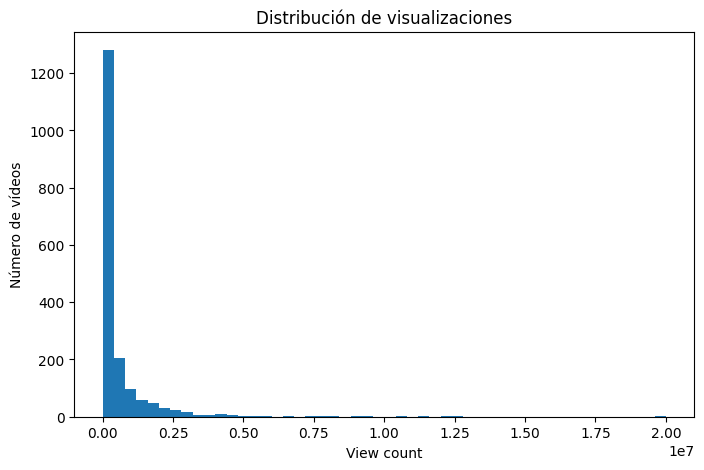

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["view_count"].dropna(), bins=50)
plt.xlabel("View count")
plt.ylabel("Número de vídeos")
plt.title("Distribución de visualizaciones")
plt.show()

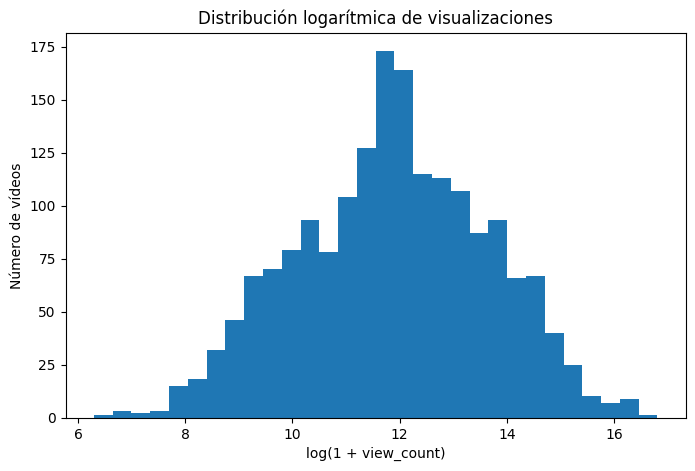

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df["view_count"].dropna()), bins=30)
plt.xlabel("log(1 + view_count)")
plt.ylabel("Número de vídeos")
plt.title("Distribución logarítmica de visualizaciones")
plt.show()

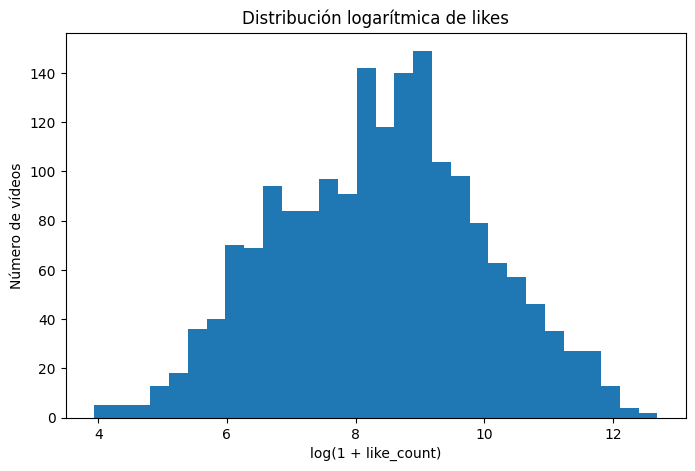

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df["like_count"].dropna()), bins=30)
plt.xlabel("log(1 + like_count)")
plt.ylabel("Número de vídeos")
plt.title("Distribución logarítmica de likes")
plt.show()